# **Impor Pustaka**

In [1]:
!pip install roboflow ultralytics
from roboflow import Roboflow
from ultralytics import YOLO
import os
import glob
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display
import random
import cv2
from tqdm import tqdm
import shutil
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.8/195.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependen

# **1. Akuisisi Data**

In [2]:
rf = Roboflow(api_key="dUJo6cQS0aGViQ30r4Qt")
project = rf.workspace("ahmad-farhan-hidayat-s-workspace").project("fish-freshness-0by5o-nqtfg")
version = project.version(3)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Fish-Freshness-3 in yolov8:: 100%|██████████| 9479/9479 [00:11<00:00, 802.95it/s] 


In [3]:
project2 = rf.workspace("ahmad-farhan-hidayat-s-workspace").project("fish-freshness-yqy4n-ggiyd")
version2 = project2.version(1)
dataset = version2.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fish-freshness-1 in yolov8:: 100%|██████████| 351/351 [00:00<00:00, 5495.85it/s]


In [4]:
def merge_yolo_datasets(source_dir, target_dir):
    splits = ['train', 'valid', 'test']
    
    for split in splits:
        for data_type in ['images', 'labels']:
            src_path = os.path.join(source_dir, split, data_type)
            tgt_path = os.path.join(target_dir, split, data_type)
            
            if os.path.exists(src_path):
                os.makedirs(tgt_path, exist_ok=True)
                
                for filename in os.listdir(src_path):
                    src_file = os.path.join(src_path, filename)
                    tgt_file = os.path.join(tgt_path, filename)
                    
                    if not os.path.exists(tgt_file):
                        shutil.move(src_file, tgt_file)
                    else:
                        base, ext = os.path.splitext(filename)
                        new_tgt_file = os.path.join(tgt_path, f"{base}_new{ext}")
                        shutil.move(src_file, new_tgt_file)

dataset_utama = "/kaggle/working/Fish-Freshness-3"
dataset_tambahan = "/kaggle/working/fish-freshness-1"

print(f"Memulai proses penggabungan dari {dataset_tambahan} ke {dataset_utama}...")
merge_yolo_datasets(dataset_tambahan, dataset_utama)
shutil.rmtree(dataset_tambahan, ignore_errors=True)
print("Penggabungan dataset selesai! Dataset utama siap digunakan untuk tahap EDA dan Training.")

Memulai proses penggabungan dari /kaggle/working/fish-freshness-1 ke /kaggle/working/Fish-Freshness-3...
Penggabungan dataset selesai! Dataset utama siap digunakan untuk tahap EDA dan Training.


# **2. Analisis Data Eksploratif**

## 2.1 Total *Bounding Box*

In [5]:
sns.set_theme(style="whitegrid", palette="muted")

LABEL_DIR = "/kaggle/working/Fish-Freshness-3/train/labels"
CLASS_NAMES = {
    0: "Fresh-Eye", 
    1: "Fresh-Skin", 
    2: "NonFresh-Eye", 
    3: "NonFresh-Skin"
}

def load_yolo_labels(label_dir):
    all_data = []
    txt_files = glob.glob(os.path.join(label_dir, "*.txt"))
    
    for file in txt_files:
        with open(file, 'r') as f:
            lines = f.readlines()
            for line in lines:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = map(float, parts[1:])
                    
                    bbox_area = width * height
                    aspect_ratio = width / height if height > 0 else 0
                    
                    all_data.append([
                        CLASS_NAMES.get(class_id, f"Class {class_id}"), 
                        x_center, y_center, width, height, bbox_area, aspect_ratio
                    ])
                    
    df = pd.DataFrame(all_data, columns=["Class", "X_Center", "Y_Center", "Width", "Height", "Bbox_Area", "Aspect_Ratio"])
    return df

print(f"Mencari file label di: {LABEL_DIR}...")
df_labels = load_yolo_labels(LABEL_DIR)
print(f"Total Bounding Box ditemukan: {len(df_labels)}")
display(df_labels.head())

Mencari file label di: /kaggle/working/Fish-Freshness-3/train/labels...
Total Bounding Box ditemukan: 9226


,Class,X_Center,Y_Center,Width,Height,Bbox_Area,Aspect_Ratio
0,Fresh-Skin,0.562143,0.445761,0.222996,0.550789,0.122824,0.404867
1,Fresh-Eye,0.547093,0.070650,0.077163,0.051699,0.003989,1.492540
2,NonFresh-Eye,0.476432,0.087078,0.078026,0.047247,0.003686,1.651444
3,Fresh-Skin,0.522748,0.468782,0.423932,0.498547,0.211350,0.850335
4,Fresh-Eye,0.098586,0.255456,0.060764,0.081019,0.004923,0.750000


## 2.2 Distribusi *Bounding Box*

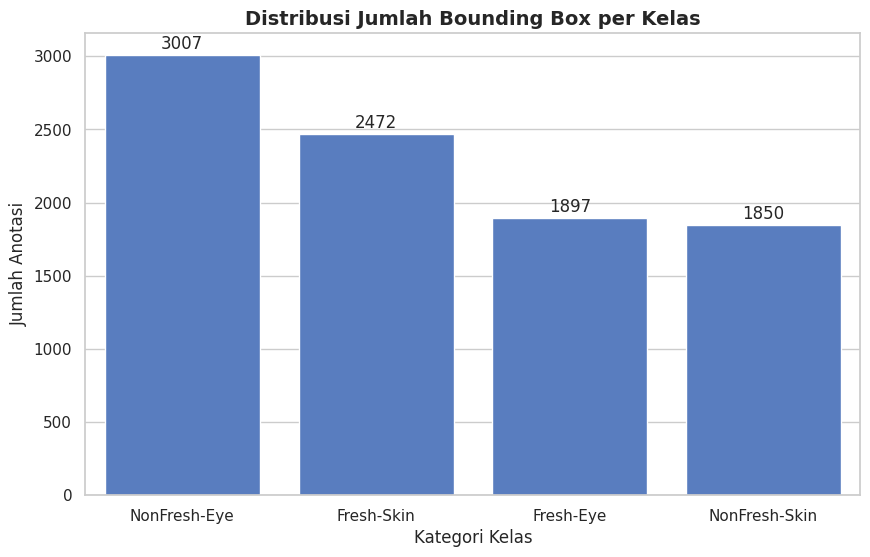

In [6]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df_labels, x="Class", order=df_labels["Class"].value_counts().index)
plt.title("Distribusi Jumlah Bounding Box per Kelas", fontsize=14, fontweight='bold')
plt.ylabel("Jumlah Anotasi")
plt.xlabel("Kategori Kelas")

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points')

plt.savefig("distribusi_bounding_box.png", dpi=300, bbox_inches='tight')
plt.show()

## 2.3 Analisis Area *Bounding Box*

Plot berhasil disimpan sebagai 'eda_spatial_analysis.png'


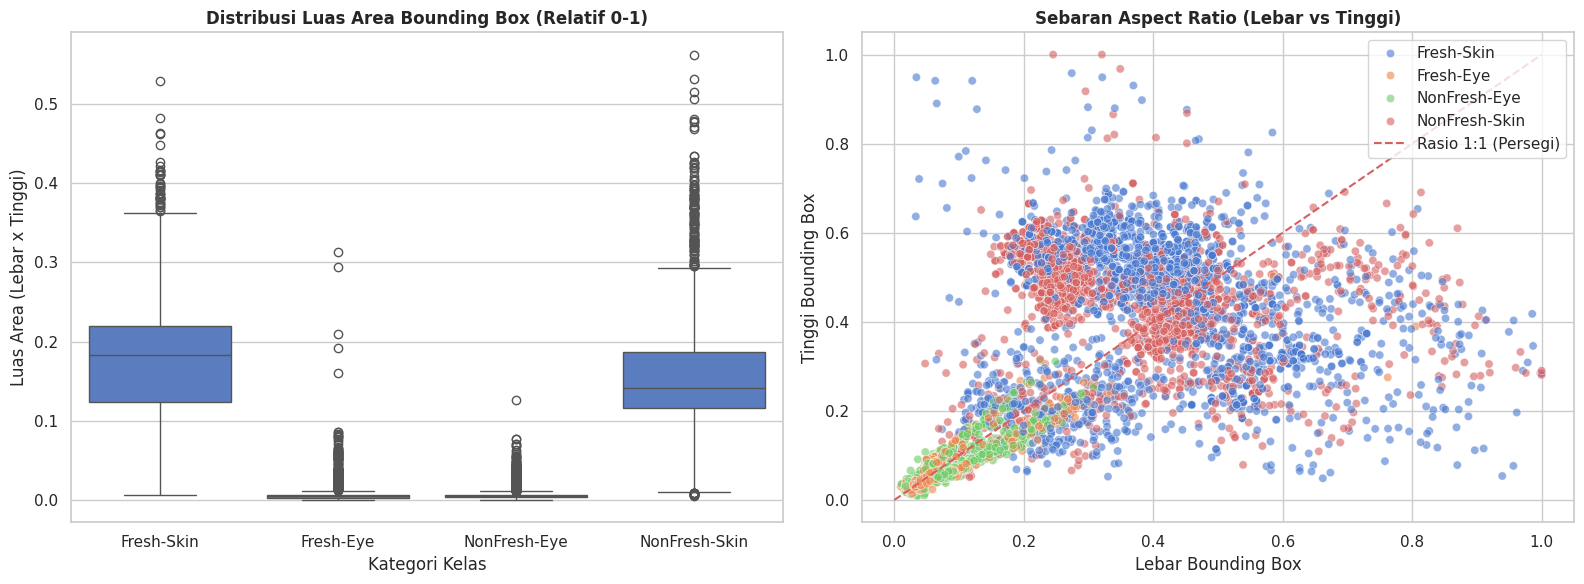

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: distribusi luas area (bbox area)
sns.boxplot(data=df_labels, x="Class", y="Bbox_Area", ax=axes[0])
axes[0].set_title("Distribusi Luas Area Bounding Box (Relatif 0-1)", fontweight='bold')
axes[0].set_ylabel("Luas Area (Lebar x Tinggi)")
axes[0].set_xlabel("Kategori Kelas")

# Plot 2: distribusi aspect ratio
sns.scatterplot(data=df_labels, x="Width", y="Height", hue="Class", alpha=0.6, ax=axes[1])
axes[1].plot([0, 1], [0, 1], 'r--', label='Rasio 1:1 (Persegi)') # Garis diagonal panduan
axes[1].set_title("Sebaran Aspect Ratio (Lebar vs Tinggi)", fontweight='bold')
axes[1].set_xlabel("Lebar Bounding Box")
axes[1].set_ylabel("Tinggi Bounding Box")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_spatial_analysis.png", dpi=300, bbox_inches='tight')
print("Plot berhasil disimpan sebagai 'eda_spatial_analysis.png'")
plt.show()

## 2.4 Analisis Integritas Kualitas Data

In [8]:
BASE_DIR = "/kaggle/working/Fish-Freshness-3"
SPLITS = ["train", "valid", "test"]

def get_file_hash(filepath):
    with open(filepath, "rb") as f:
        file_hash = hashlib.md5()
        chunk = f.read(8192)
        while chunk:
            file_hash.update(chunk)
            chunk = f.read(8192)
    return file_hash.hexdigest()

global_hashes = {}
missing_labels_total = 0
cross_split_leakage = []
same_split_duplicates = []

for split in SPLITS:
    img_dir = os.path.join(BASE_DIR, split, "images")
    lbl_dir = os.path.join(BASE_DIR, split, "labels")
    
    if not os.path.exists(img_dir):
        continue
        
    image_files = glob.glob(os.path.join(img_dir, "*.jpg")) + glob.glob(os.path.join(img_dir, "*.jpeg"))
    print(f"Memproses partisi '{split}' ({len(image_files)} gambar)...")
    
    for img_path in image_files:
        base_name = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(lbl_dir, f"{base_name}.txt")
        
        # 2.4.1. CEK MISSING ANNOTATION
        if not os.path.exists(label_path):
            missing_labels_total += 1
            
        # 2.4.2 CEK DUPLIKASI DAN DATA LEAKAGE
        img_hash = get_file_hash(img_path)
        
        if img_hash in global_hashes:
            original_split = global_hashes[img_hash]['split']
            original_path = global_hashes[img_hash]['path']
            
            if original_split != split:
                cross_split_leakage.append((original_split, split, base_name))
            else:
                same_split_duplicates.append((split, base_name))
        else:
            global_hashes[img_hash] = {'path': img_path, 'split': split}

print("\n" + "="*50)
print("HASIL AUDIT KUALITAS DATA")
print("="*50)
print(f"- Gambar tanpa label (total dari semua folder) : {missing_labels_total}")
print(f"- Duplikat di dalam partisi yang sama          : {len(same_split_duplicates)}")
print(f"- Kebocoran data antarpartisi (data leakage)   : {len(cross_split_leakage)}")

if len(cross_split_leakage) > 0:
    print("\nDitemukan data leakage pada file berikut:")
    for leak in cross_split_leakage[:5]: # Tampilkan max 5
        print(f"    - Gambar '{leak[2]}' bocor dari folder '{leak[0]}' ke '{leak[1]}'")
else:
    print("\n✅ Dataset bersih, tidak ada data leakage antar partisi train/val/test.")

Memproses partisi 'train' (3953 gambar)...
Memproses partisi 'valid' (480 gambar)...
Memproses partisi 'test' (477 gambar)...

HASIL AUDIT KUALITAS DATA
- Gambar tanpa label (total dari semua folder) : 0
- Duplikat di dalam partisi yang sama          : 0
- Kebocoran data antarpartisi (data leakage)   : 0

✅ Dataset bersih, tidak ada data leakage antar partisi train/val/test.


# **3. Pelatihan Model YOLO**

In [9]:
model = YOLO('yolov8s.pt') 

results = model.train(
    data="/kaggle/working/Fish-Freshness-3/data.yaml",
    epochs=50,  
    imgsz=800,
    batch=16,
    patience=15,
    name='yolov8s-model',
    
    # Augmentasi
    degrees=15.0,
    hsv_s=0.5,
    hsv_v=0.4,
    fliplr=0.5,
    mosaic=1.0,
    copy_paste=0.3,
    mixup=0.2,
    
    # Pengaturan Belajar
    cos_lr=True,
    lr0=0.001,

    # Optimizer & Regularisasi
    optimizer='AdamW',
    weight_decay=0.0005,
    warmup_epochs=3,
)

Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/Fish-Freshness-3/data.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s-model, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_m

# **4. Pemangkasan**

In [10]:
yolo_model = YOLO("runs/detect/yolov8s-model/weights/best.pt") 

output_dir = "/kaggle/working/dataset_klasifikasi"
classes = ["Segar", "Tidak_Segar"]

for split in ["train", "valid"]:
    for cls in classes:
        os.makedirs(os.path.join(output_dir, split, cls), exist_ok=True)

def process_and_crop(image_dir, split_name):
    image_paths = glob.glob(os.path.join(image_dir, "*.jpg")) + glob.glob(os.path.join(image_dir, "*.jpeg"))
    
    for img_path in tqdm(image_paths, desc=f"Cropping {split_name} data"):
        img = cv2.imread(img_path)
        if img is None: continue
            
        results = yolo_model(img, verbose=False)
        for r in results:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                class_name = yolo_model.names[int(box.cls[0])]
                
                folder_class = "Tidak_Segar" if "NonFresh" in class_name else "Segar"
                    
                h, w = img.shape[:2]
                y1, y2 = max(0, y1), min(h, y2)
                x1, x2 = max(0, x1), min(w, x2)
                cropped_img = img[y1:y2, x1:x2]
                
                if cropped_img.size == 0: continue
                
                base_name = os.path.basename(img_path)
                save_path = os.path.join(output_dir, split_name, folder_class, f"{folder_class}_{x1}_{y1}_{base_name}")
                cv2.imwrite(save_path, cropped_img)

TRAIN_IMG_DIR = "/kaggle/working/Fish-Freshness-3/train/images"
VALID_IMG_DIR = "/kaggle/working/Fish-Freshness-3/valid/images"

process_and_crop(TRAIN_IMG_DIR, "train")
process_and_crop(VALID_IMG_DIR, "valid")
print("Cropping Selesai")

Cropping valid data: 100%|██████████| 480/480 [00:58<00:00,  8.24it/s]

Cropping Selesai


# **5. Pelatihan Model EfficientNet**

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/kaggle/working/dataset_klasifikasi'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'valid']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=2) for x in ['train', 'valid']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes

model = models.efficientnet_b3(pretrained=True)
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    
    best_f1 = 0.0 

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        for phase in ['train', 'valid']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss, running_corrects = 0.0, 0
            
            all_preds = []
            all_labels = []

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            print(f'{phase} Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | F1-Score: {epoch_f1:.4f}')

            if phase == 'valid' and epoch_f1 > best_f1:
                best_f1 = epoch_f1
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'Menyimpan model terbaik baru (F1-Score: {best_f1:.4f})')
        
        print('-' * 20)

    time_elapsed = time.time() - since
    print(f'Training selesai dalam {time_elapsed // 60:.0f} menit {time_elapsed % 60:.0f} detik')
    print(f'Best Validation F1-Score: {best_f1:.4f}')

    model.load_state_dict(best_model_wts)
    return model

model_ft = train_model(model, criterion, optimizer, num_epochs=10)

torch.save(model_ft.state_dict(), '/kaggle/working/efficientnet_best.pth')
print("\nPenyimpanan model selesai. Model siap digunakan!")

The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 167MB/s]


Epoch 1/10
train Loss: 0.3590 | Acc: 0.8433 | F1-Score: 0.8433
valid Loss: 0.2323 | Acc: 0.9121 | F1-Score: 0.9111
Menyimpan model terbaik baru (F1-Score: 0.9111)
--------------------
Epoch 2/10
train Loss: 0.2556 | Acc: 0.8976 | F1-Score: 0.8976
valid Loss: 0.2012 | Acc: 0.9245 | F1-Score: 0.9237
Menyimpan model terbaik baru (F1-Score: 0.9237)
--------------------
Epoch 3/10
train Loss: 0.2054 | Acc: 0.9184 | F1-Score: 0.9184
valid Loss: 0.2363 | Acc: 0.9035 | F1-Score: 0.9029
--------------------
Epoch 4/10
train Loss: 0.1927 | Acc: 0.9249 | F1-Score: 0.9249
valid Loss: 0.1896 | Acc: 0.9255 | F1-Score: 0.9252
Menyimpan model terbaik baru (F1-Score: 0.9252)
--------------------
Epoch 5/10
train Loss: 0.1749 | Acc: 0.9345 | F1-Score: 0.9345
valid Loss: 0.2086 | Acc: 0.9160 | F1-Score: 0.9151
--------------------
Epoch 6/10
train Loss: 0.1525 | Acc: 0.9421 | F1-Score: 0.9421
valid Loss: 0.2065 | Acc: 0.9226 | F1-Score: 0.9223
--------------------
Epoch 7/10
train Loss: 0.1456 | Acc: 0.9

# **6. Evaluasi**


6.1 Normalized Confusion Matrix:


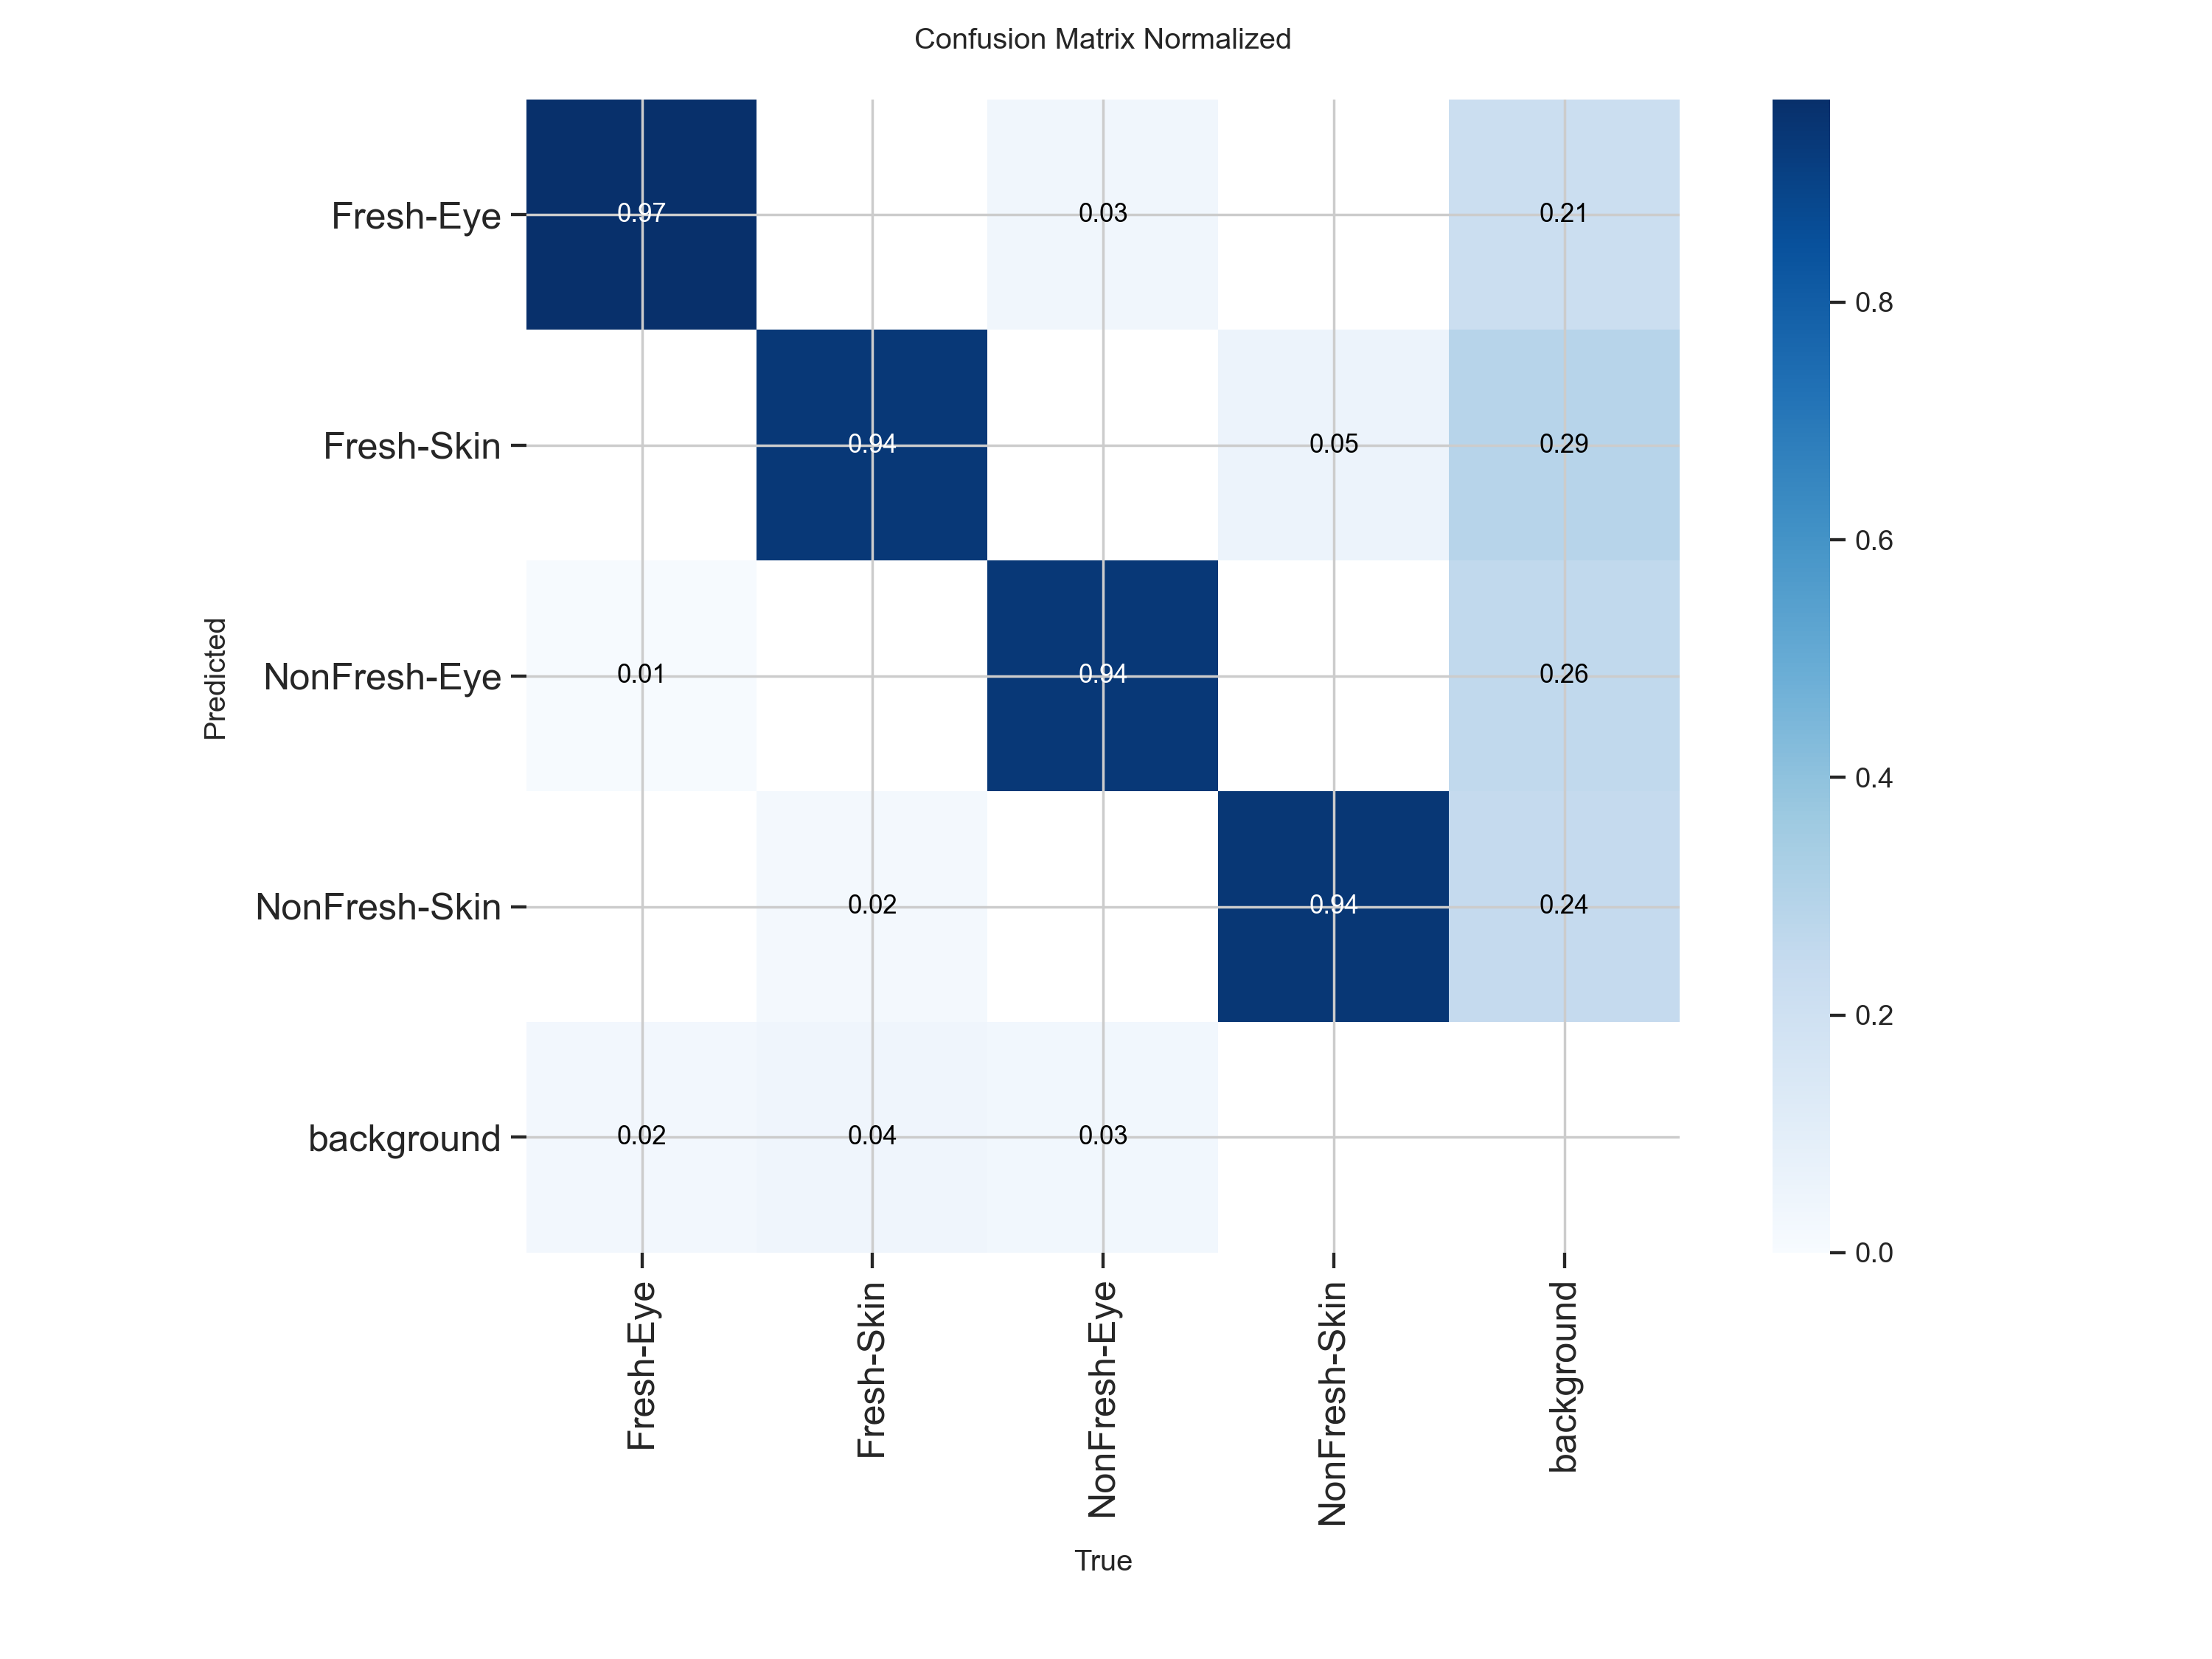


6.2 Kurva F1-Score (Confidence vs F1):


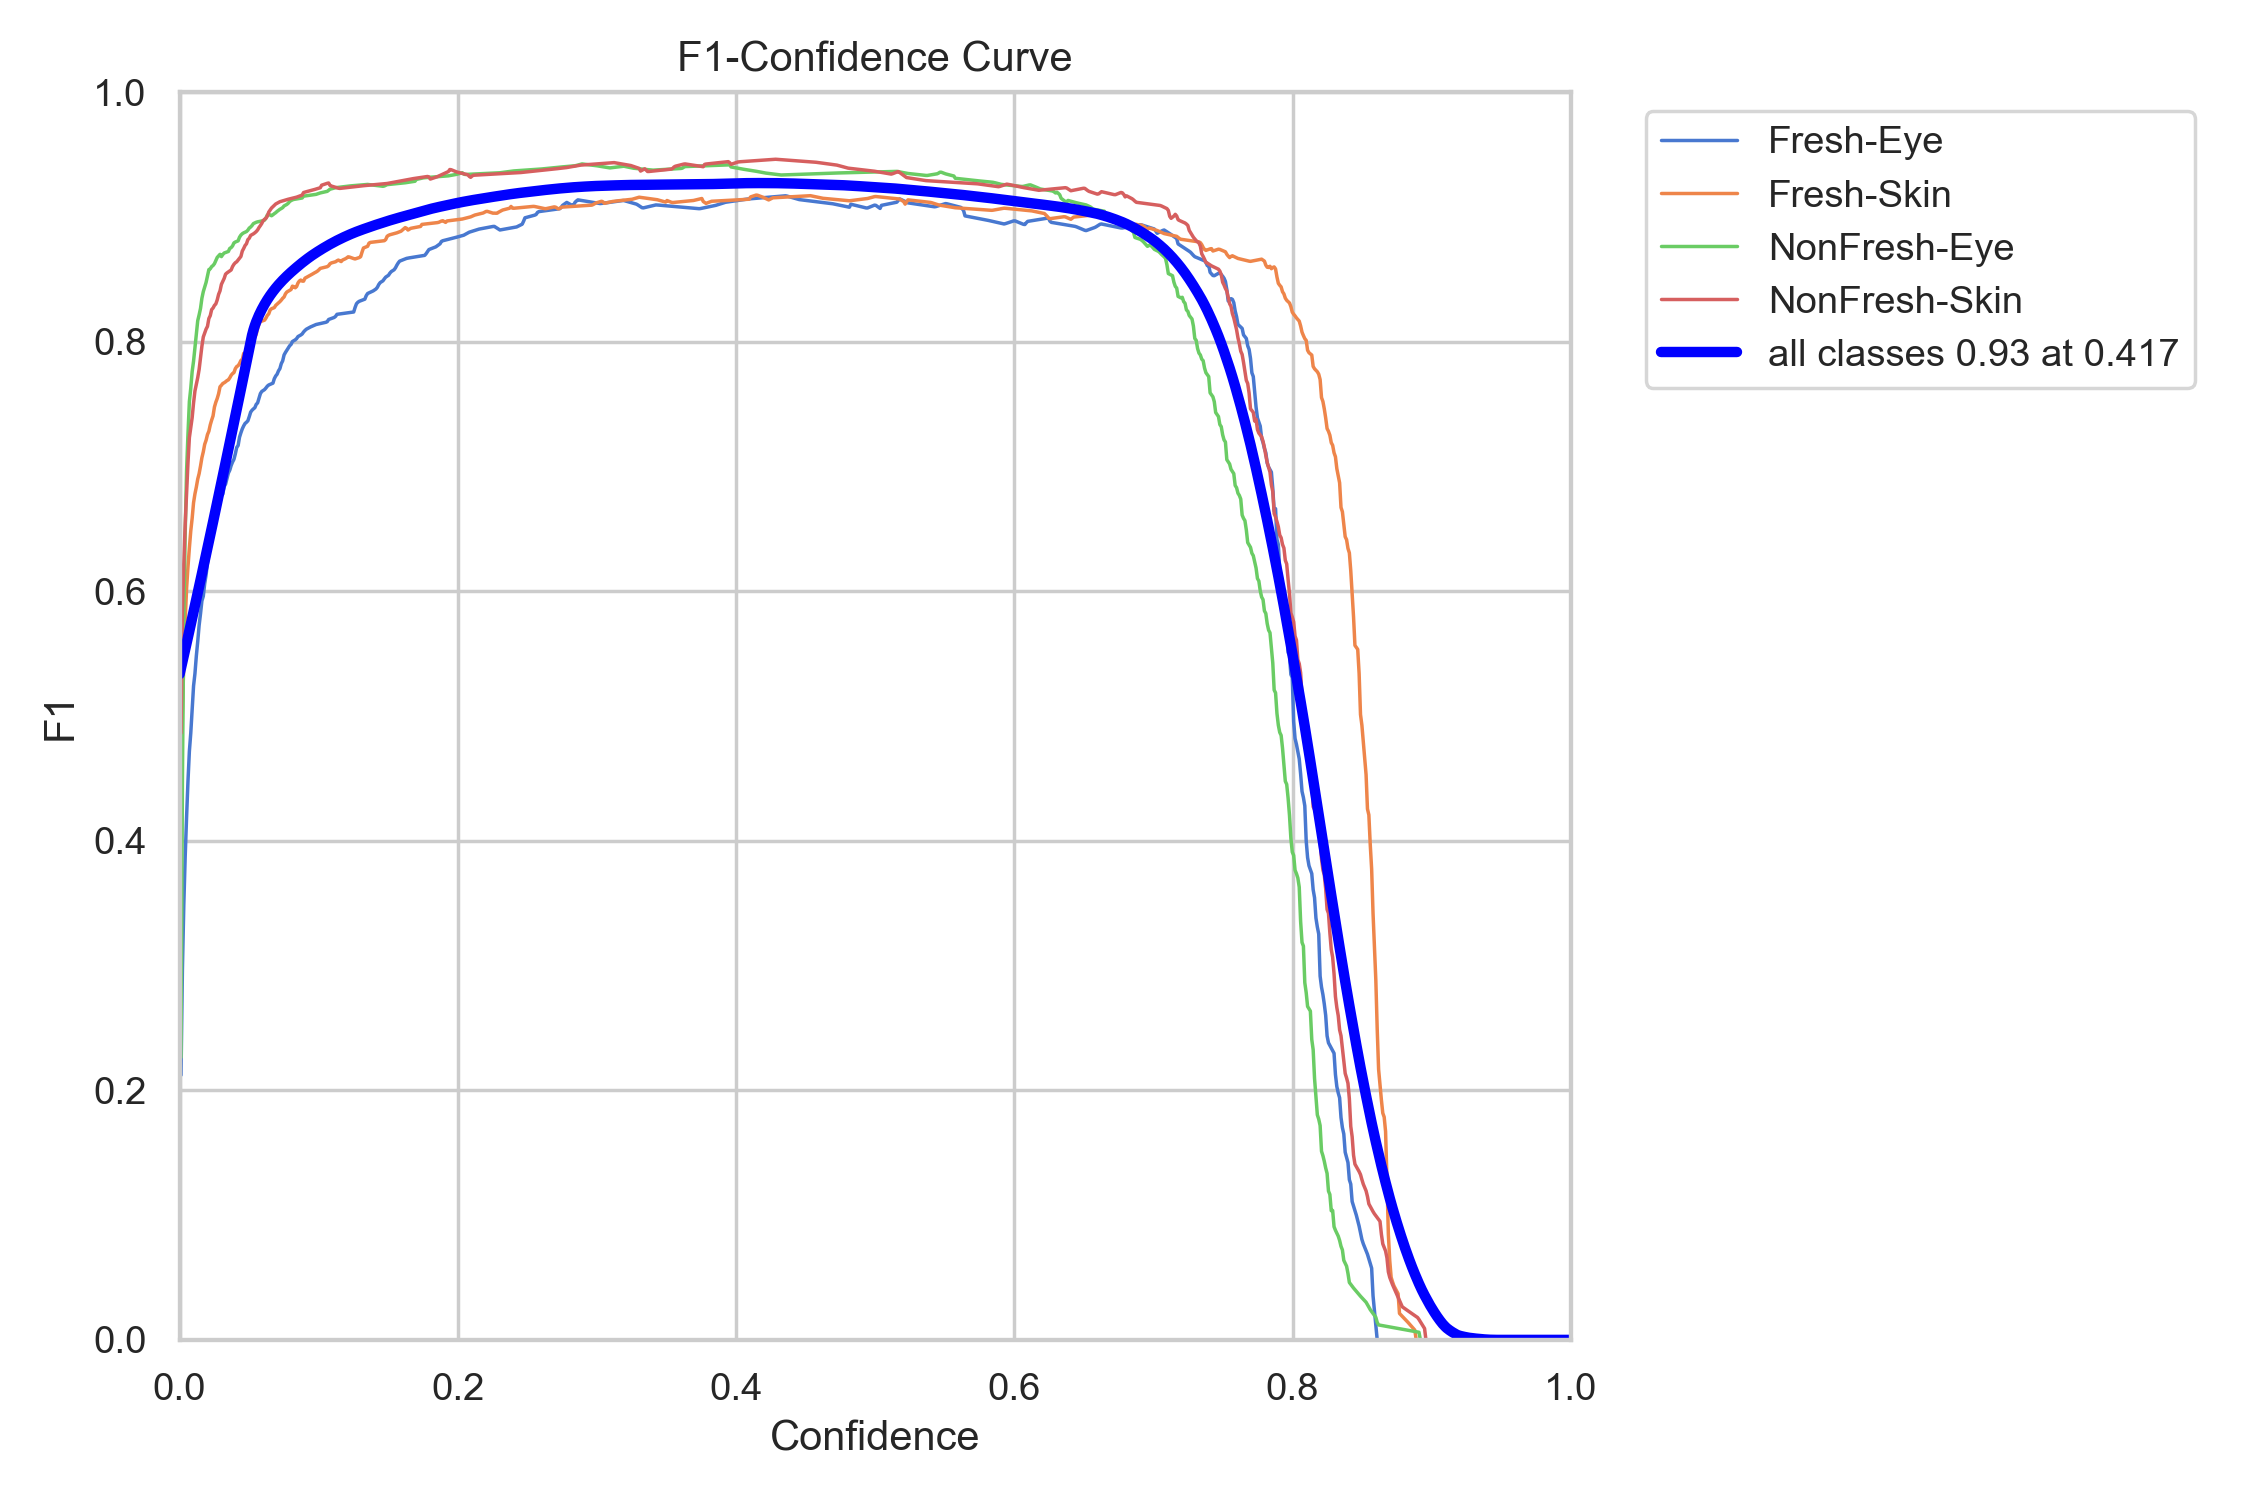


6.3 Rangkuman Metrik Akhir (berdasarkan model terbaik):
- Epoch Terbaik : Epoch ke-49
- mAP50         : 0.9653 (96.53%)
- mAP50-95      : 0.6378 (63.78%)
- Precision     : 0.9266 (92.66%)
- Recall        : 0.9299 (92.99%)
- F1-Score      : 0.9282 (92.82%)


In [12]:
RUN_DIR = "/kaggle/working/runs/detect/yolov8s-model"

cm_path = os.path.join(RUN_DIR, "confusion_matrix_normalized.png")
if os.path.exists(cm_path):
    print("\n6.1 Normalized Confusion Matrix:")
    display(Image(filename=cm_path, width=700))

f1_path = os.path.join(RUN_DIR, "BoxF1_curve.png")
if os.path.exists(f1_path):
    print("\n6.2 Kurva F1-Score (Confidence vs F1):")
    display(Image(filename=f1_path, width=700))

csv_path = os.path.join(RUN_DIR, "results.csv")
if os.path.exists(csv_path):
    print("\n6.3 Rangkuman Metrik Akhir (berdasarkan model terbaik):")
    
    df_results = pd.read_csv(csv_path)
    df_results.columns = df_results.columns.str.strip()
    
    best_epoch_idx = df_results['metrics/mAP50-95(B)'].idxmax()
    best_metrics = df_results.iloc[best_epoch_idx]
    
    mAP50 = best_metrics['metrics/mAP50(B)']
    mAP50_95 = best_metrics['metrics/mAP50-95(B)']
    precision = best_metrics['metrics/precision(B)']
    recall = best_metrics['metrics/recall(B)']
    best_epoch_num = int(best_metrics['epoch']) if 'epoch' in best_metrics else best_epoch_idx + 1
    
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)
    
    print(f"- Epoch Terbaik : Epoch ke-{best_epoch_num}")
    print(f"- mAP50         : {mAP50:.4f} ({mAP50*100:.2f}%)")
    print(f"- mAP50-95      : {mAP50_95:.4f} ({mAP50_95*100:.2f}%)")
    print(f"- Precision     : {precision:.4f} ({precision*100:.2f}%)")
    print(f"- Recall        : {recall:.4f} ({recall*100:.2f}%)")
    print(f"- F1-Score      : {f1_score:.4f} ({f1_score*100:.2f}%)")
else:
    print("\nFile results.csv tidak ditemukan.")


CLASSIFICATION REPORT (EFFICIENTNET)
              precision    recall  f1-score   support

       Segar       0.95      0.93      0.94       476
 Tidak_Segar       0.94      0.96      0.95       571

    accuracy                           0.95      1047
   macro avg       0.95      0.95      0.95      1047
weighted avg       0.95      0.95      0.95      1047



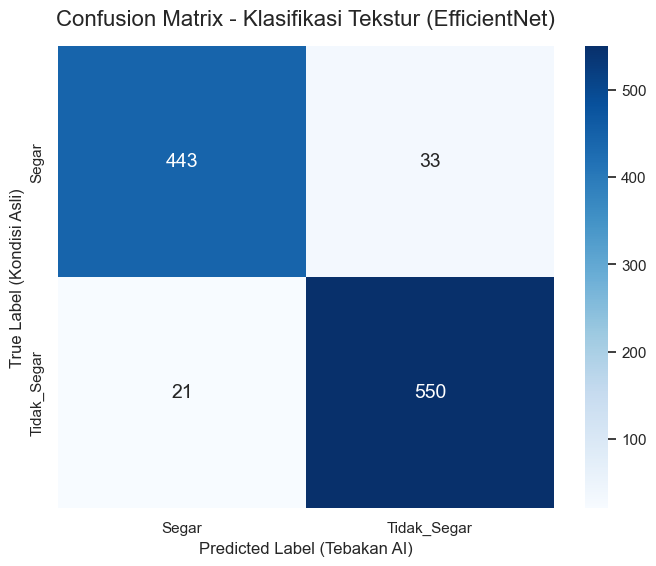


Selesai! Gambar Confusion Matrix berhasil disimpan di: /kaggle/working/confusion_matrix_efficientnet.png


In [13]:
model_ft.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['valid']:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

print("\n" + "="*40)
print("CLASSIFICATION REPORT (EFFICIENTNET)")
print("="*40)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 14})

plt.title("Confusion Matrix - Klasifikasi Tekstur (EfficientNet)", fontsize=16, pad=15)
plt.xlabel("Predicted Label (Tebakan AI)", fontsize=12)
plt.ylabel("True Label (Kondisi Asli)", fontsize=12)

save_cm_path = "/kaggle/working/confusion_matrix_efficientnet.png"
plt.savefig(save_cm_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"\nSelesai! Gambar Confusion Matrix berhasil disimpan di: {save_cm_path}")

# **7. Inferensi**

MEMULAI PENGUJIAN INFERENSI TWO-STAGE PIPELINE
Memuat bobot model YOLO dari: /kaggle/working/runs/detect/yolov8s-model/weights/best.pt

Melakukan inferensi pada gambar: IMG_7114_jpeg.rf.83b6d239cea47bb344dd5ed89a128482.jpg

DETAIL DETEKSI & KLASIFIKASI:
------------------------------------------------------------
Fitur 1     : NonFresh-Eye (YOLO Conf: 83.49%)
Koordinat   : Titik Atas-Kiri (1444, 3587) | Titik Bawah-Kanan (1680, 3829)
Hasil AI 2  : Tidak Segar (EfficientNet)
------------------------------------------------------------
Fitur 2     : NonFresh-Skin (YOLO Conf: 77.27%)
Koordinat   : Titik Atas-Kiri (1171, 844) | Titik Bawah-Kanan (1809, 3194)
Hasil AI 2  : Tidak Segar (EfficientNet)
------------------------------------------------------------
KESIMPULAN AKHIR SISTEM : IKAN TIDAK SEGAR


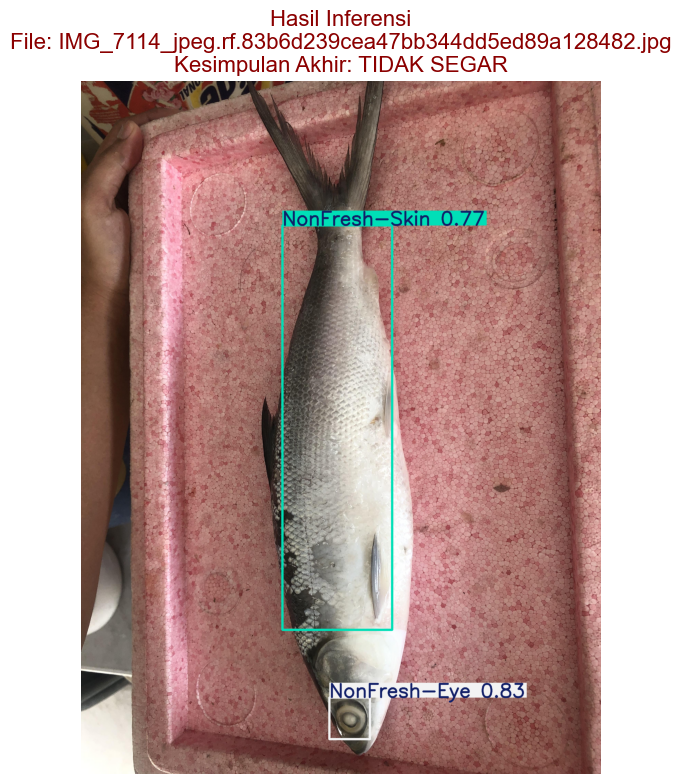


Gambar inferensi berhasil disimpan sebagai 'inference_twostage_IMG_7114_jpeg.rf.83b6d239cea47bb344dd5ed89a128482.png'


In [14]:
from PIL import Image as PILImage

MODEL_PATH = "/kaggle/working/runs/detect/yolov8s-model/weights/best.pt" 
VALID_DIR = "/kaggle/working/Fish-Freshness-3/valid/images"

print("MEMULAI PENGUJIAN INFERENSI TWO-STAGE PIPELINE")
print("="*60)

print(f"Memuat bobot model YOLO dari: {MODEL_PATH}")
model_yolo = YOLO(MODEL_PATH)

model_ft.eval()

image_files = glob.glob(os.path.join(VALID_DIR, "*.jpg")) + glob.glob(os.path.join(VALID_DIR, "*.jpeg"))

if not image_files:
    print("Error: Tidak ada gambar di folder validasi.")
else:
    sample_img_path = random.choice(image_files)
    img_name = os.path.basename(sample_img_path)
    print(f"\nMelakukan inferensi pada gambar: {img_name}")

    results = model_yolo.predict(source=sample_img_path, conf=0.25, save=False, verbose=False)
    result = results[0]
    
    original_img_pil = PILImage.open(sample_img_path).convert("RGB")

    print("\nDETAIL DETEKSI & KLASIFIKASI:")
    print("-" * 60)
    
    is_non_fresh = False
    
    if len(result.boxes) == 0:
        print("Tidak ada objek (mata/kulit) yang terdeteksi oleh YOLO.")
        final_conclusion = "TIDAK DAPAT DISIMPULKAN"
    else:
        for i, box in enumerate(result.boxes):
            class_id = int(box.cls[0])
            yolo_class_name = model_yolo.names[class_id]
            conf = float(box.conf[0])
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            
            cropped_img = original_img_pil.crop((x1, y1, x2, y2))
            
            input_tensor = data_transforms['valid'](cropped_img).unsqueeze(0).to(device)
            
            with torch.no_grad():
                outputs = model_ft(input_tensor)
                _, preds = torch.max(outputs, 1)
                eff_class = class_names[preds[0].item()]
            
            if eff_class == "Tidak_Segar":
                is_non_fresh = True
            
            print(f"Fitur {i+1}     : {yolo_class_name} (YOLO Conf: {conf * 100:.2f}%)")
            print(f"Koordinat   : Titik Atas-Kiri ({x1}, {y1}) | Titik Bawah-Kanan ({x2}, {y2})")
            print(f"Hasil AI 2  : {eff_class.replace('_', ' ')} (EfficientNet)")
            print("-" * 60)
            
        final_conclusion = "TIDAK SEGAR" if is_non_fresh else "SEGAR"
        print(f"KESIMPULAN AKHIR SISTEM : IKAN {final_conclusion}")
        print("="*60)

    img_with_boxes = result.plot()
    img_rgb = cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 8))
    plt.imshow(img_rgb)
    plt.axis('off')
    
    title_color = 'darkred' if is_non_fresh else 'darkgreen'
    if final_conclusion == "TIDAK DAPAT DISIMPULKAN": title_color = 'black'
        
    plt.title(f"Hasil Inferensi\nFile: {img_name}\nKesimpulan Akhir: {final_conclusion}", 
              fontweight='bold', fontsize=16, color=title_color)
    plt.tight_layout()

    save_filename = f"inference_twostage_{os.path.splitext(img_name)[0]}.png"
    plt.savefig(save_filename, dpi=300, bbox_inches='tight')
    
    plt.show()
    print(f"\nGambar inferensi berhasil disimpan sebagai '{save_filename}'")

In [15]:
shutil.rmtree("/kaggle/working/Fish-Freshness-3", ignore_errors=True)